---
title: "Lecture 12: Nonlinear least-squares"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture12_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Nonlinear Least Squares

Just as with linear systems, we can sometimes fail to find an exact solution and need to find a least-squares solution, rootfinding problems can sometime fail to have an exact solution and we must turn instead to an optimization problem called **nonlinear least-squares**.

## Nonlinear least squares

::: {.callout-note icon=false}
## Definition: Nonlinear least-squares problem
Given a function $\mathbf{f}(\mathbf{x})$ mapping from $\mathbb{R}^n$ to $\mathbb{R}^m$, the **nonlinear least-squares problem** is to find $\mathbf{x} \in \mathbb{R}^n$ such that $\|\mathbf{f}(\mathbf{x})\|_2$ is minimized.
:::

. . .

This problem is equivalent to minimizing the square of the objective (since it is already positive) and so we may instead minimize the objective function $\phi(\mathbf{x}) = \mathbf{f}(\mathbf{x})^\top \mathbf{f}(\mathbf{x})$.

## Gauss-Newton method

Just as with the rootfinding problem, we may substitute a linear model function in place of $\mathbf{f}$.  

. . .

At estimate $\mathbf{x}_k$, we define the linear model $$\mathbf{q}(\mathbf{x}) = \mathbf{f}(\mathbf{x}_k) + \mathbf{A}_k(\mathbf{x} - \mathbf{x}_k),$$ where $\mathbf{A}_k$ is the $m \times n$ Jacobian matrix or an approximation of it using the techniques from Lecture 11.  

. . .

In the rootfinding problem, we sought a next iterate that satisfied $\mathbf{q}(\mathbf{x}_{k+1}) = \mathbf{0}$, but now we aim the define $\mathbf{x}_{k+1}$ to be the value that minimizes $\|\mathbf{q}(\mathbf{x})\|_2$.  This defines the **Gauss-Newton method**.

. . .

Given $\mathbf{f}$ and a starting value $\mathbf{x}_1$, for each $k = 1, 2, 3, \cdots$,

1. Compute $\mathbf{y}_k = \mathbf{f}(\mathbf{x}_k)$ and $\mathbf{A}_k$, the exact or approximate Jacobian matrix at $\mathbf{x}_k$.
2. Solve the linear least-squares problem $\text{argmin} \|\mathbf{A}_k \mathbf{s}_k + \mathbf{y}_k\|_2$ for $\mathbf{s}_k$.
3. Let $\mathbf{x}_{k+1} = \mathbf{x}_k + \mathbf{s}_k$.

## Implementation

Our `newtonsys` and `levenberg` functions work as Gauss-Newton with exact Jacobian and approximate Jacobian, respectively, since we used the `\` operator, which solves the linear least-squares problem!

In [19]:
# | echo: false

"""
    newtonsys(f,jac,x1[;maxiter,ftol,xtol])

Use Newton's method to find a root of a system of equations, starting from 'x1'.
The functions 'f' and 'jac' should return the residual vector and the Jacobian
matrix, respectively.  Returns the history of root estimates as a vector of 
vectors.

The optional keyword parameters set the maximum number of iterations and the 
stopping tolerance for values of 'f' and changes in 'x'.
"""
function newtonsys(f,jac,x1;maxiter=40,ftol=100*eps(),xtol=1000*eps())
    x = [float(x1)]
    y, J = f(x1), jac(x1)
    delx = Inf         # for initial pass below
    k = 1

    while (norm(delx) > xtol) && (norm(y) > ftol)
        delx = -(J\y)                # Newton step
        push!(x, x[k] + delx)        # append to history
        k += 1
        y, J = f(x[k]), jac(x[k])

        if k == maxiter
            @warn "Maximum number of iterations reached."
            break
        end
    end
    return x
end

newtonsys

In [20]:
# | echo: false

"""
    fdjac(f,x0[,y0])

Compute a finite-difference approximation of the Jacobian matrix for 'f' at 'x0',
where 'y0 = f(x0)' may be given.
"""
function fdjac(f,x0,y0=f(x0))
    δ = sqrt(eps())*max(norm(x0),1)       # FD step size
    m,n = length(y0),length(x0)
    if n == 1
        J = (f(x0+δ) - y0) / δ
    else
        J = zeros(m,n)
        x = copy(x0)
        for j in 1:n
            x[j] += δ
            J[:,j] = (f(x) - y0) / δ
            x[j] -= δ
        end
    end
    return J
end

fdjac

In [21]:
# | echo: false

"""
    levenberg(f,x1[;maxiter,ftol,xtol])

Use Levenberg's quasi-Newton iteration to find a root of the system 'f'
starting from 'x1'.  Returns the history of root estimates as a vector
of vectors.

The optional keyword parameters set the maximum number of iterations and
the stopping tolerance for values of 'f' and changes in 'x'.
"""
function levenberg(f,x1;maxiter=40,ftol=1e-12,xtol=1e-12)
    x = [float(x1)]
    yk = f(x1)
    k = 1; s = Inf;
    A = fdjac(f,x[k],yk)       # start with FD Jacobian
    jac_is_new = true

    λ = 10;
    while (norm(s) > xtol) && (norm(yk) > ftol)
        # Compute the proposed step.
        B = A'*A + λ*I
        z = A'*yk
        s = -(B\z)

        x̂ = x[k] + s
        ŷ = f(x̂)

        # Do we accept the result?
        if norm(ŷ) < norm(yk)     # accept
            λ = λ/10              # get closer to Newton
            # Broyden update of the Jacobian
            A += (ŷ - yk - A*s)*(s'/(s'*s))
            jac_is_new = false

            push!(x,x̂)
            yk = ŷ
            k += 1
        else                      # don't accept
            # Get closer to gradient descent.
            λ = 4λ
            # Re-initialize the Jacobian if its out of date.
            if !jac_is_new
                A = fdjac(f,x[k],yk)
                jac_is_new = true
            end
        end
        if k==maxiter
            @warn "Maximum number of iterations reached."
            break
        end
    end
    return x
end

levenberg

In [22]:
# | echo: false

using LinearAlgebra
using Plots
using Printf

In [23]:
g(x) = [sin(x[1]+x[2]),cos(x[1]-x[2]),exp(x[1]-x[2])]
p = [1,1];

---

The function $\mathbf{g}(\mathbf{x}) - \mathbf{g}(\mathbf{p})$ has zero residual at $\mathbf{p}$.  We make perturbations of this function to create nonzero residuals.

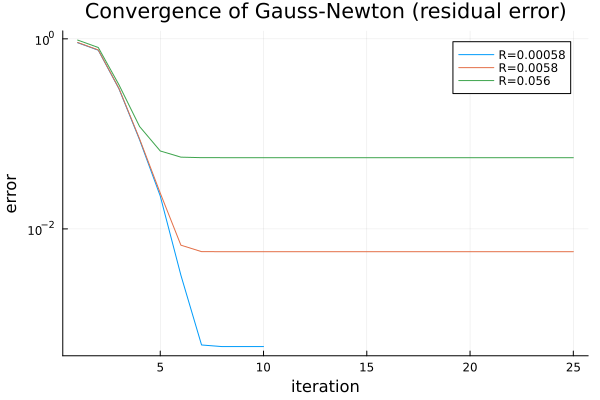

In [24]:
plt = plot(xlabel="iteration",yaxis=(:log10,"error"), title="Convergence of Gauss-Newton (residual error)")
for R in [1e-3, 1e-2, 1e-1]
    # Define the perturbed function.
    f(x) = g(x) - g(p) + R*normalize([-1,1,-1])
    x = levenberg(f,[0,0])
    r = x[end]
    res_err = @. norm(f(x))
    normres = norm(f(r))
    plot!(res_err,label=@sprintf("R=%.2g",normres))
end
plt

---

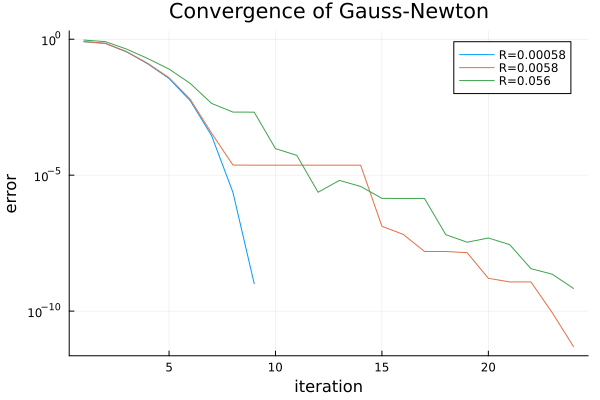

In [25]:
plt = plot(xlabel="iteration",yaxis=(:log10,"error"), title="Convergence of Gauss-Newton")
for R in [1e-3, 1e-2, 1e-1]
    # Define the perturbed function.
    f(x) = g(x) - g(p) + R*normalize([-1,1,-1])
    x = levenberg(f,[0,0])
    r = x[end]
    err = [norm(x-r) for x in x[1:end-1]]
    normres = norm(f(r))
    plot!(err,label=@sprintf("R=%.2g",normres))
end
plt

. . .

In the least perturbed case, the convergence is roughly quadratic, and the next least perturbed case exhibits initially quadratic and then linear convergence, while the most perturbed case exhibits nearly entirely linear convergence.

## Nonlinear data fitting

Suppose that $(t_i,y_i)$ for $i = 1, \cdots, m$ are given data points.  We wish to model this data by a function $g(t,\mathbf{x})$ that depends upon the unknown parameters $x_1, x_2, \cdots, x_n$ in an arbitrary (nonlinear) way.  

. . .

As in the linear case, a natural approach is to minimize the discrepancy between the data $y_i$ and the model output $g(t_i, \mathbf{x})$ in a least-squares sense. 
We define the **misfit** function $$\mathbf{f}(\mathbf{x}) = [g(t_i,\mathbf{x})-y_i]_{i=1, \cdots, m}$$ and seek to minimize $\|\mathbf{f}(\mathbf{c})\|_2^2$ over all coefficient vectors $\mathbf{c}$.

. . . 

Note that the choice of form of the function $g$ is up to the modeler and may be chosen given understanding of the data and underlying mechanisms, or simply so that $g$ has enouch algebraic complexity to fit to the data well.  

. . .

If the dependence on $\mathbf{c}$ is linear, $$g(t,\mathbf{c}) = c_1 g_1(t) + c_2g_2(t) + \cdots + c_m g_m(t),$$ then $\text{argmin} \|\mathbf{f}(\mathbf{c})\|_2^2$ is a *linear* least-squares problem.

---

{{< video https://youtu.be/3OKIZlGZZkg 
    title="What is the Michaelis-Menten equation?"
    aspect-ratio="16x9"
    width="1000"
>}}

---

In this demo, we'll play with data representing the enzyme reaction rate $v(s)$ under the *Michaelis-Menten* kinetics with $V = 2$ and $K_m = 1/2$, $$v(s) = \frac{Vs}{K_m + s}.$$ 

In [27]:
m = 25;
s = range(0.05,6,length=m)
v̂ = @. 2*s/(0.5+s)                     # exact data
v = @. v̂ + 0.15*cos(2*exp(s/16)*s);    # smooth additive noise    

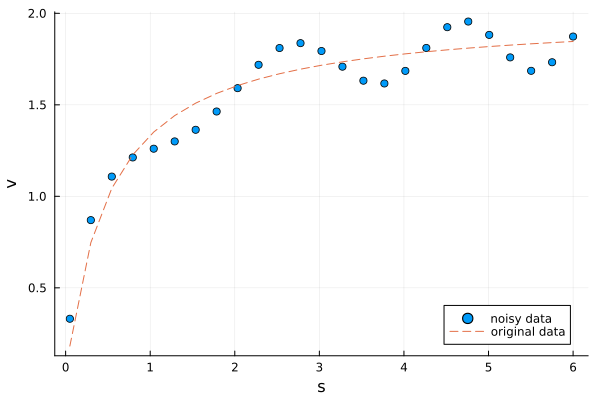

In [29]:
scatter(s,v,label="noisy data", xlabel="s", ylabel="v", leg=:bottomright)
plot!(s, v̂, l=:dash, label="original data")

---

We'll now imagine that we only have access to the noisy data and attempt to use nonlinear least-squares to learn the parameters in the model function $v(s)$.  Here, $v$ is our $g$ function, $s$ is our $t$ variable, and the coefficients $\mathbf{c}$ are the values of $V$ and $K_m$.

In [34]:
function misfit(x)
    V, Km = x      #rename components for clarity
    return @. V*s/(Km+s) - v
end

misfit (generic function with 1 method)

In [37]:
function misfitjac(x)
    V, Km = x      #rename components for clarity
    J = zeros(m,2)
    J[:,1] = @. s/(Km+s)        # dw/dV
    J[:,2] = @. -V*s/(Km+s)^2   # dw/dKm 
    return J
end

misfitjac (generic function with 1 method)

In [38]:
x₁ = [1, 0.75]
x = newtonsys(misfit,misfitjac,x₁)

@show V, Km = x[end]   # final values

(V, Km) = x[end] = [1.96865259837822, 0.46930373074166293]


2-element Vector{Float64}:
 1.96865259837822
 0.46930373074166293

In [39]:
model = s -> V*s/(Km+s)

#9 (generic function with 1 method)

---

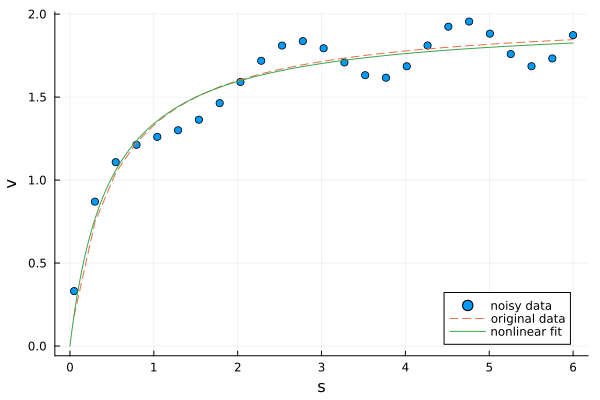

In [40]:
plot!(model,0,6,label="nonlinear fit")

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->